# Clinical Readmission Risk Prediction using Electronic Health Records (EHR)

## Business Problem

Hospital readmissions within 30 days are a significant challenge for healthcare providers, leading to increased treatment costs, resource utilization, and reduced quality of patient care. Identifying patients at high risk of readmission enables hospitals to implement targeted interventions, optimize discharge planning, and improve patient outcomes.

In this project, we develop machine learning models to predict whether a diabetic patient will be readmitted within 30 days after discharge using Electronic Health Records (EHR) collected from 130 US hospitals.

## Objective

- Analyze clinical and demographic factors associated with hospital readmission.
- Build predictive machine learning models.
- Compare multiple algorithms.
- Interpret the most influential clinical features contributing to readmission risk.

In [2]:
# ==========================
# Import Libraries
# ==========================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

from xgboost import XGBClassifier

import shap

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)
pd.set_option("display.max_columns", None)

## 1. Load Dataset

In [3]:
df = pd.read_csv("data/diabetic_data.csv")

DATA_PATH = "data/diabetic_data.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape: {df.shape}")

df.head()
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (101766, 50)
Dataset Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 2. Initial Data Inspection

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,NaN,NaN,NaN,165201645.622978,102640295.983457,12522.0,84961194.0,152388987.0,230270887.5,443867222.0
patient_nbr,101766.0,NaN,NaN,NaN,54330400.694947,38696359.346534,135.0,23413221.0,45505143.0,87545949.75,189502619.0
race,101766,6,Caucasian,76099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,101766,3,Female,54708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,101766,10,[70-80),26068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,101766,10,?,98569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,101766.0,NaN,NaN,NaN,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,NaN,NaN,NaN,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,NaN,NaN,NaN,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,NaN,NaN,NaN,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0


In [6]:
df.sample(5, random_state=42)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
35956,110939484,19274094,Caucasian,Female,[70-80),?,1,1,6,11,UN,InternalMedicine,68,0,20,0,0,0,250.8,599,263,5,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
60927,170328306,65634327,Caucasian,Male,[50-60),?,1,1,1,1,HM,?,20,0,7,0,0,0,780,427,E941,8,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
79920,245688426,100657359,Caucasian,Female,[60-70),?,3,6,1,4,HM,?,21,3,23,1,0,2,715,733,724,7,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
50078,150826224,83144448,Caucasian,Male,[30-40),?,2,1,1,12,CP,Gastroenterology,28,0,19,0,0,1,494,277,117,7,NaN,NaN,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,>30
44080,135993852,65234214,AfricanAmerican,Female,[60-70),?,1,2,7,1,?,?,21,0,6,0,0,0,403,584,428,7,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,<30


## 3. Check Duplicate Records

In [7]:
print(f"Duplicate Rows : {df.duplicated().sum()}")

Duplicate Rows : 0


## 4. Missing Value Analysis

In [8]:
df.replace("?", np.nan, inplace=True)

In [9]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing = missing[missing["Missing Values"]>0].sort_values(
    by="Percentage",
    ascending=False
)

missing

,Missing Values,Percentage
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


## 5. Visualize Missing Values

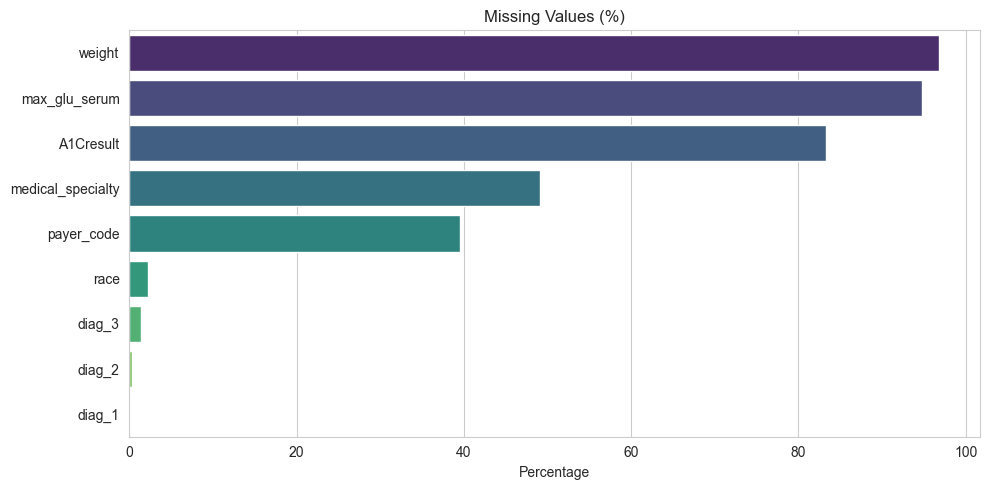

In [10]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=missing["Percentage"],
    y=missing.index,
    palette="viridis"
)

plt.title("Missing Values (%)")
plt.xlabel("Percentage")
plt.ylabel("")
plt.tight_layout()

plt.show()

## 6. Data Cleaning

High-quality data is essential for building reliable machine learning models. This section focuses on improving data quality by handling missing values, removing irrelevant features, correcting data types, and preparing the dataset for feature engineering and model development.

### Dataset Shape Before Cleaning

In [11]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 101,766
Columns: 50


### Identify Unique Values

In [12]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{'='*60}")
    print(f"{col}")
    print(df[col].value_counts(dropna=False).head(10))


race
race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

gender
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

age
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

weight
weight
NaN          98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

payer_code
payer_code
NaN    40256
MC     32439
HM      6274
SP      5007
BC      4655
MD      3532
CP      2533
UN      2448
CM      1937
OG      1033
Name: count, dtype: int64

medical_specialty
medical_specialty
NaN                           49949

### Drop Irrelevant Columns

In [13]:
drop_cols = [
    "encounter_id",
    "patient_nbr"
]

df.drop(columns=drop_cols, inplace=True)

print(f"New Shape: {df.shape}")

New Shape: (101766, 48)


### Missing Value Percentage

In [14]:
missing = (
    df.isnull()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing[missing > 0]

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64

### Handle Missing Values

In [15]:
missing[missing > 40]

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
dtype: float64

### Drop High-Missing Columns

In [16]:
high_missing = [
    "weight",
    "payer_code",
    "medical_specialty"
]

df.drop(columns=high_missing, inplace=True)

print(df.shape)

(101766, 45)


### Check Remaining Missing Values

In [17]:
df.isnull().sum().sort_values(ascending=False).head(10)

max_glu_serum          96420
A1Cresult              84748
race                    2273
diag_3                  1423
diag_2                   358
diag_1                    21
admission_source_id        0
num_lab_procedures         0
time_in_hospital           0
gender                     0
dtype: int64

## 7. Exploratory Data Analysis

The objective of Exploratory Data Analysis (EDA) is to understand the distribution of patient demographics, clinical characteristics, and hospital utilization patterns associated with hospital readmission. These insights help guide feature engineering and model development.

### Target Variable Distribution

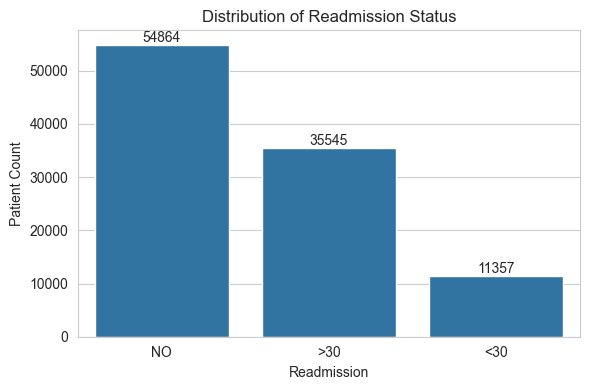

In [18]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="readmitted",
    order=df["readmitted"].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Readmission Status")
plt.xlabel("Readmission")
plt.ylabel("Patient Count")
plt.tight_layout()
plt.show()

Observation:
Most patients were not readmitted within 30 days, indicating potential class imbalance. This will be considered during model development and evaluation.

### Age Distribution

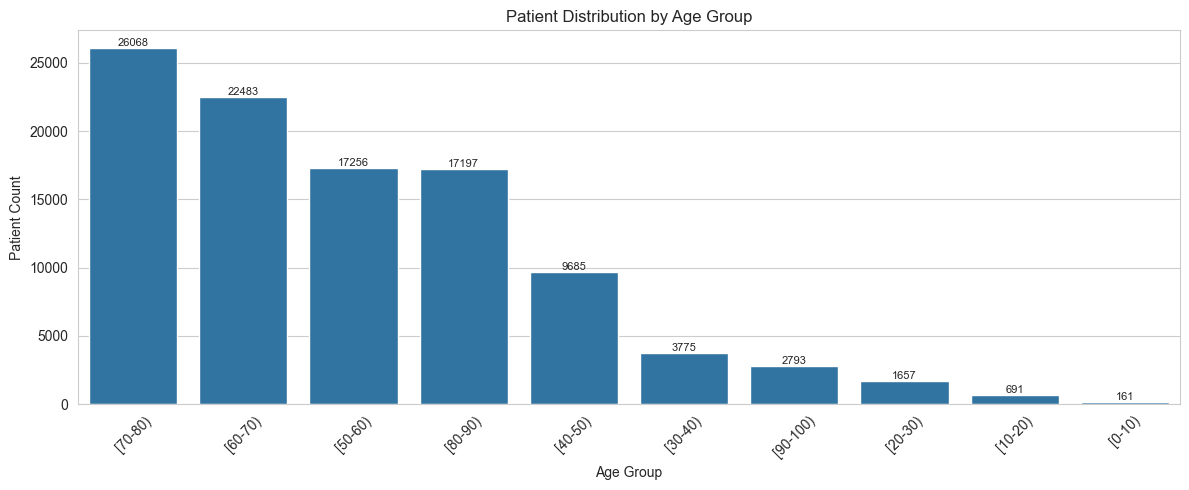

In [19]:
plt.figure(figsize=(12,5))

ax = sns.countplot(
    data=df,
    x="age",
    order=df["age"].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container, fontsize=8)

plt.xticks(rotation=45)
plt.title("Patient Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Patient Count")
plt.tight_layout()
plt.show()

Observation:
Hospital encounters are concentrated among older patients, particularly between 60 and 80 years of age.

### Gender Distribution

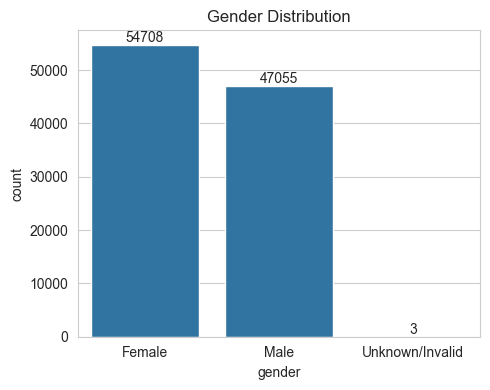

In [20]:
plt.figure(figsize=(5,4))

ax = sns.countplot(
    data=df,
    x="gender"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Gender Distribution")
plt.tight_layout()
plt.show()

### Race Distribution

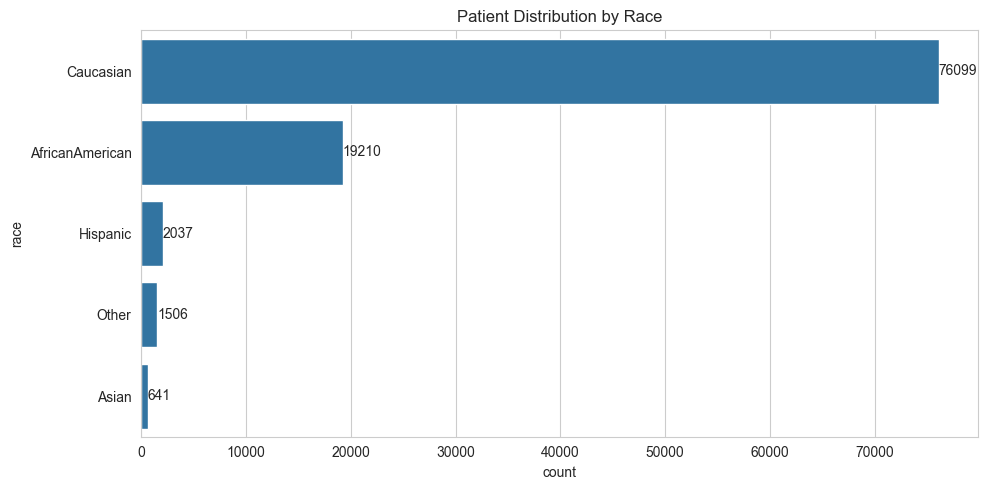

In [21]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    y="race",
    order=df["race"].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Patient Distribution by Race")
plt.tight_layout()
plt.show()

### Time in Hospital

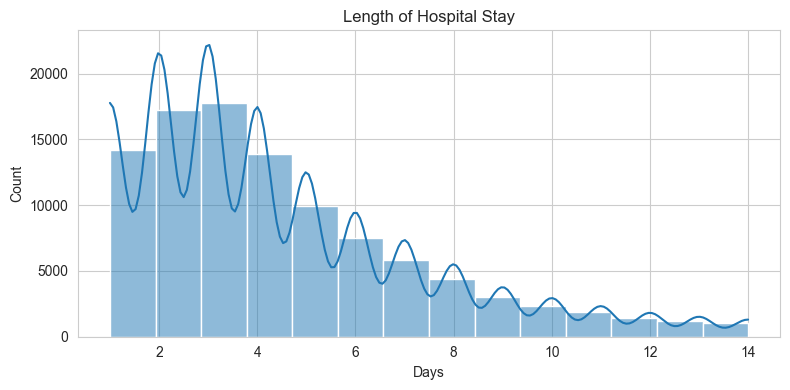

In [22]:
plt.figure(figsize=(8,4))

sns.histplot(
    df["time_in_hospital"],
    bins=14,
    kde=True
)

plt.title("Length of Hospital Stay")
plt.xlabel("Days")
plt.tight_layout()
plt.show()

### Number of Medications

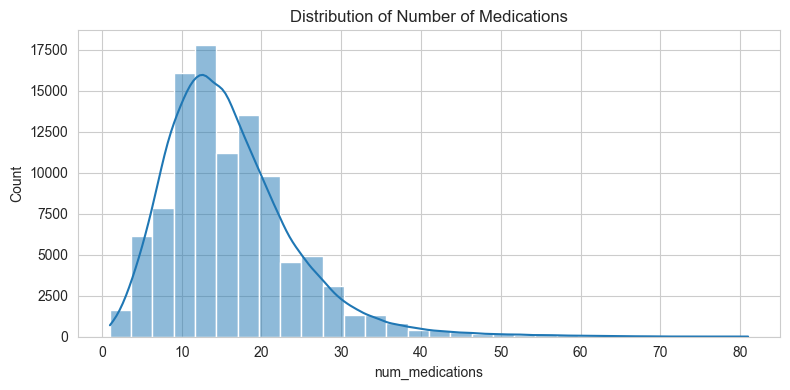

In [23]:
plt.figure(figsize=(8,4))

sns.histplot(
    df["num_medications"],
    bins=30,
    kde=True
)

plt.title("Distribution of Number of Medications")
plt.tight_layout()
plt.show()

### Number of Lab Procedures

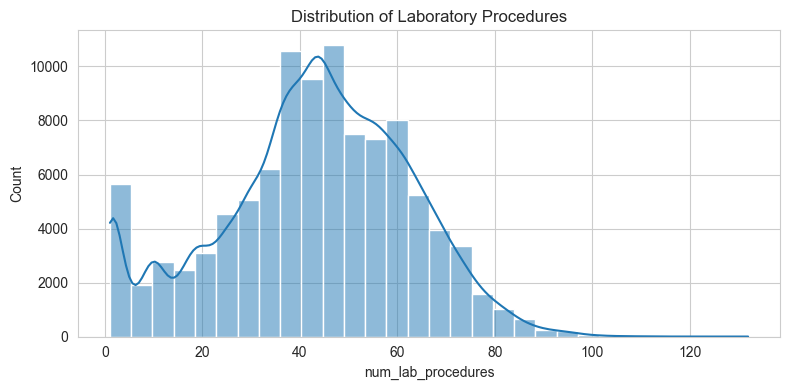

In [24]:
plt.figure(figsize=(8,4))

sns.histplot(
    df["num_lab_procedures"],
    bins=30,
    kde=True
)

plt.title("Distribution of Laboratory Procedures")
plt.tight_layout()
plt.show()

### Readmission by Age Group

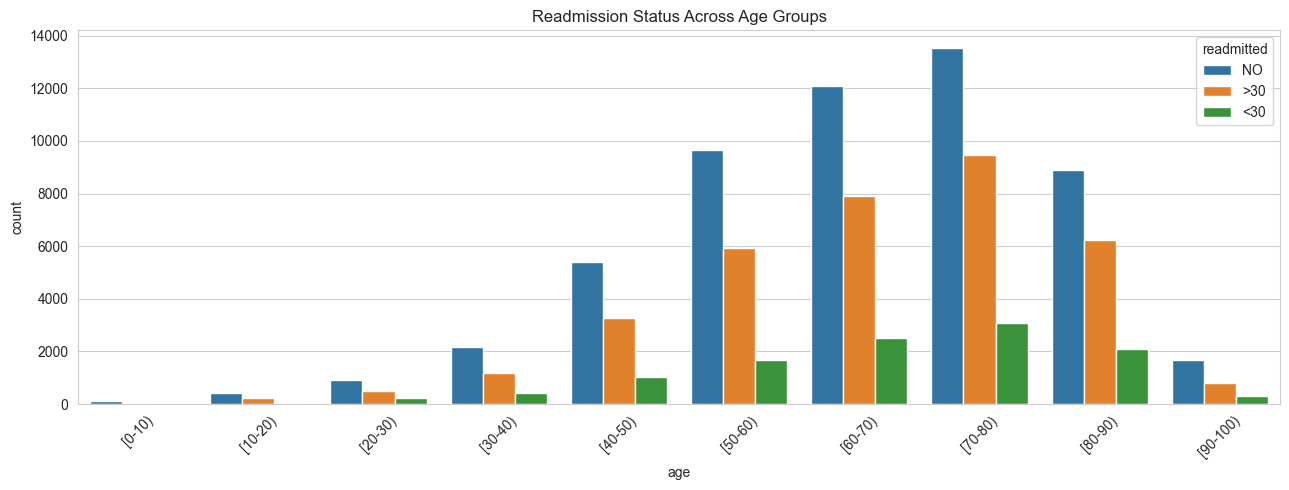

In [25]:
plt.figure(figsize=(13,5))

sns.countplot(
    data=df,
    x="age",
    hue="readmitted"
)

plt.xticks(rotation=45)
plt.title("Readmission Status Across Age Groups")
plt.tight_layout()
plt.show()

### Readmission by Gender

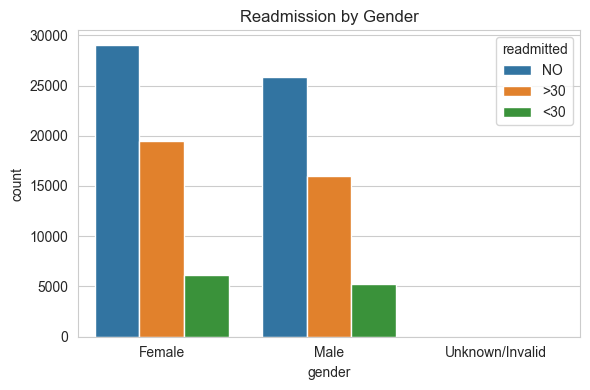

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="gender",
    hue="readmitted"
)

plt.title("Readmission by Gender")
plt.tight_layout()
plt.show()

### Correlation Heatmap (Numerical Features)

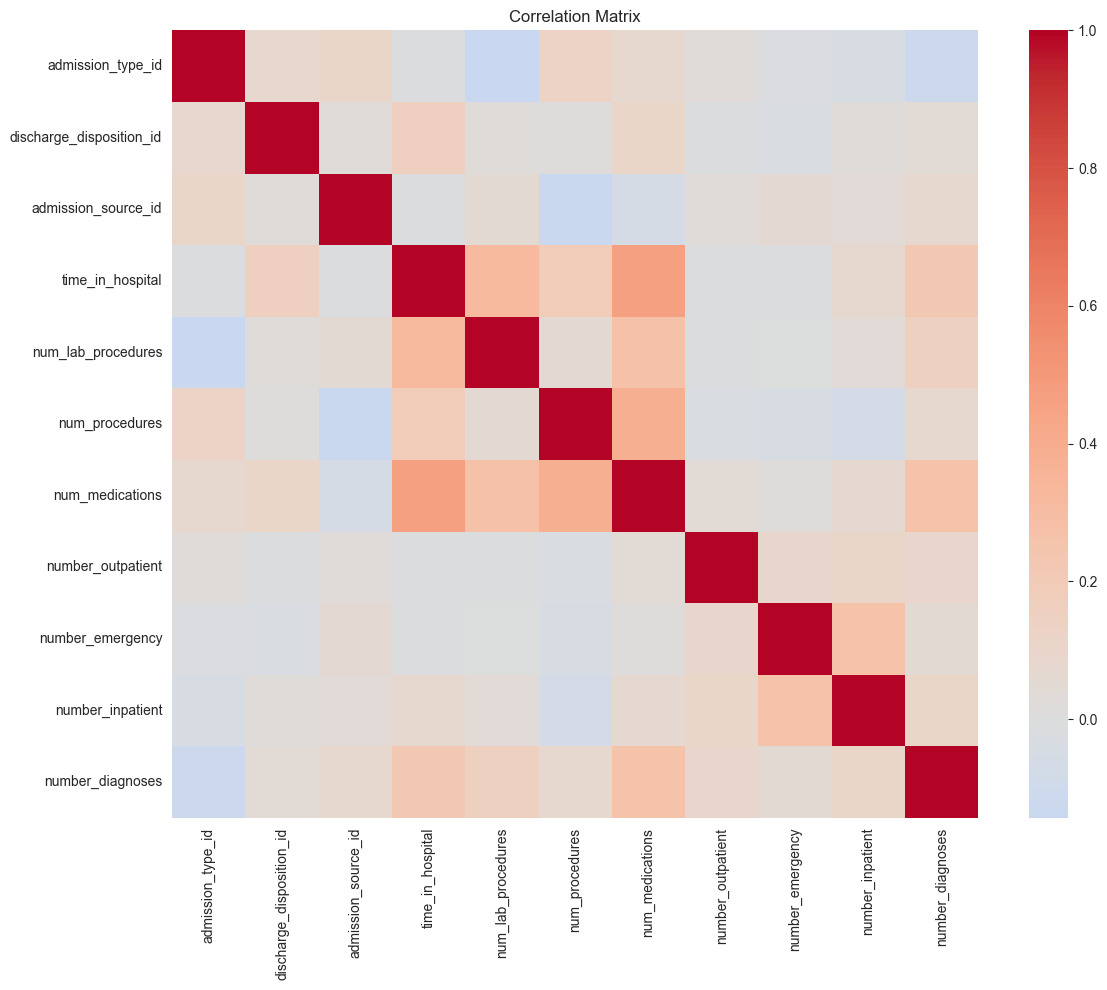

In [27]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(12,10))

sns.heatmap(
    df[numerical_columns].corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Boxplots for Outlier Detection

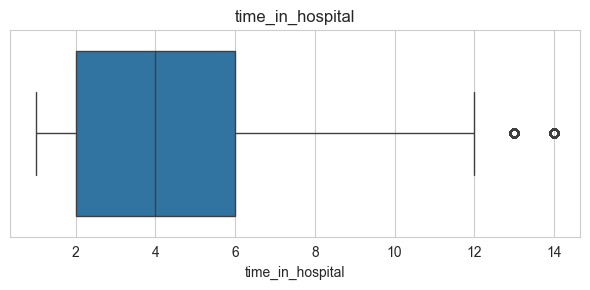

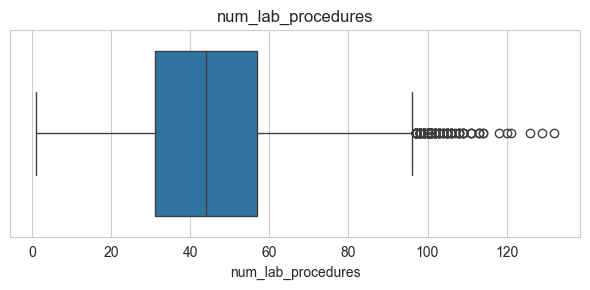

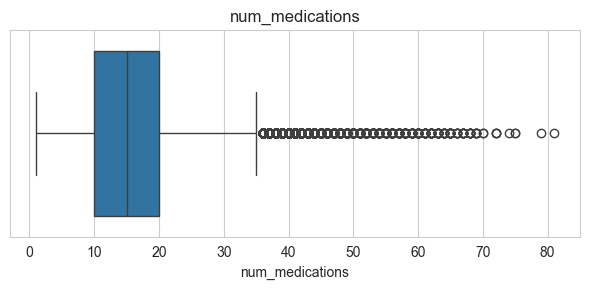

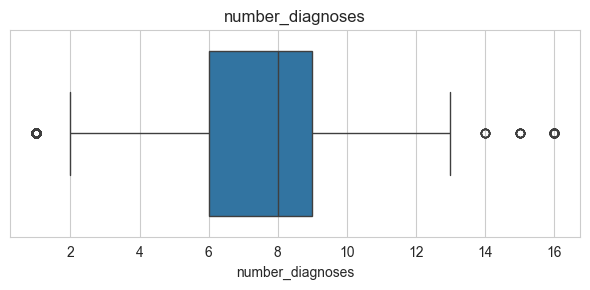

In [28]:
cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_medications",
    "number_diagnoses"
]

for col in cols:
    
    plt.figure(figsize=(6,3))
    
    sns.boxplot(
        x=df[col]
    )
    
    plt.title(col)
    plt.tight_layout()
    plt.show()

## 8. Feature Engineering

Feature engineering transforms raw clinical variables into more informative representations that improve model performance and interpretability.

The engineered features are based on healthcare domain knowledge and patient utilization patterns rather than arbitrary transformations.

In [29]:
# Create a copy to preserve the cleaned dataset
df_fe = df.copy()

print(df_fe.shape)

(101766, 45)


### Create Binary Target Variable

In [30]:
df_fe["readmitted"] = df_fe["readmitted"].apply(
    lambda x: 1 if x == "<30" else 0
)

df_fe["readmitted"].value_counts()

readmitted
0    90409
1    11357
Name: count, dtype: int64

### Convert Age Ranges to Numeric Midpoints

In [31]:
age_mapping = {
    "[0-10)":5,
    "[10-20)":15,
    "[20-30)":25,
    "[30-40)":35,
    "[40-50)":45,
    "[50-60)":55,
    "[60-70)":65,
    "[70-80)":75,
    "[80-90)":85,
    "[90-100)":95
}

df_fe["age"] = df_fe["age"].map(age_mapping)

### Total Hospital Visits

In [32]:
df_fe["total_visits"] = (
    df_fe["number_outpatient"] +
    df_fe["number_emergency"] +
    df_fe["number_inpatient"]
)

### Medication Change Flag

In [33]:
df_fe["change"] = df_fe["change"].map({
    "No":0,
    "Ch":1
})

### Diabetes Medication Flag

In [34]:
df_fe["diabetesMed"] = df_fe["diabetesMed"].map({
    "No":0,
    "Yes":1
})

### Gender

In [35]:
df_fe["gender"] = df_fe["gender"].replace("Unknown/Invalid", np.nan)

In [36]:
df_fe.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,total_visits
0,Caucasian,Female,5,6,25,1,1,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,0,0,0
1,Caucasian,Female,15,1,1,7,3,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,1,1,0,0
2,AfricanAmerican,Female,25,1,1,7,2,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,1,0,3
3,Caucasian,Male,35,1,1,7,2,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,1,1,0,0
4,Caucasian,Male,45,1,1,7,1,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,1,1,0,0


In [37]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 46 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101763 non-null  object
 2   age                       101766 non-null  int64 
 3   admission_type_id         101766 non-null  int64 
 4   discharge_disposition_id  101766 non-null  int64 
 5   admission_source_id       101766 non-null  int64 
 6   time_in_hospital          101766 non-null  int64 
 7   num_lab_procedures        101766 non-null  int64 
 8   num_procedures            101766 non-null  int64 
 9   num_medications           101766 non-null  int64 
 10  number_outpatient         101766 non-null  int64 
 11  number_emergency          101766 non-null  int64 
 12  number_inpatient          101766 non-null  int64 
 13  diag_1                    101745 non-null  object
 14  diag

In [38]:
print(df_fe.shape)

(101766, 46)


## 9. Clinical Feature Engineering

### Inspect Diagnosis Columns

The diagnosis features (`diag_1`, `diag_2`, and `diag_3`) contain ICD-9 diagnosis codes representing the patient's primary, secondary, and tertiary diagnoses. Before feature engineering, we examine their cardinality, missing values, and the most frequent diagnoses to determine an appropriate transformation strategy.

In [39]:
diagnosis_cols = ["diag_1", "diag_2", "diag_3"]

for col in diagnosis_cols:
    print(f"\n{'='*60}")
    print(f"{col.upper()}")
    print(f"{'='*60}")

    print(f"Unique Values : {df_fe[col].nunique():,}")
    print(f"Missing Values: {df_fe[col].isna().sum():,}")

    display(df_fe[col].value_counts(dropna=False).head(15))


DIAG_1
Unique Values : 716
Missing Values: 21


diag_1
428      6862
414      6581
786      4016
410      3614
486      3508
427      2766
491      2275
715      2151
682      2042
434      2028
780      2019
996      1967
276      1889
38       1688
250.8    1680
Name: count, dtype: int64


DIAG_2
Unique Values : 748
Missing Values: 358


diag_2
276       6752
428       6662
250       6071
427       5036
401       3736
496       3305
599       3288
403       2823
414       2650
411       2566
250.02    2074
707       1999
585       1871
584       1649
491       1545
Name: count, dtype: int64


DIAG_3
Unique Values : 789
Missing Values: 1,423


diag_3
250       11555
401        8289
276        5175
428        4577
427        3955
414        3664
496        2605
403        2357
585        1992
272        1969
599        1941
NaN        1423
V45        1389
250.02     1369
707        1360
Name: count, dtype: int64

### Analyze High-Cardinality Features

High-cardinality categorical variables can significantly increase feature dimensionality after one-hot encoding. This analysis helps identify features that require specialized handling instead of direct encoding.

In [40]:
categorical_cols = df_fe.select_dtypes(include="object").columns

high_cardinality = (
    pd.DataFrame({
        "Feature": categorical_cols,
        "Unique Values": [
            df_fe[col].nunique()
            for col in categorical_cols
        ]
    })
    .sort_values("Unique Values", ascending=False)
    .reset_index(drop=True)
)

high_cardinality

,Feature,Unique Values
0,diag_3,789
1,diag_2,748
2,diag_1,716
3,race,5
4,repaglinide,4
5,metformin,4
6,glipizide,4
7,glimepiride,4
8,nateglinide,4
9,chlorpropamide,4


### Map ICD-9 Diagnosis Codes to Clinical Categories

Instead of treating each ICD-9 diagnosis code as an independent category, diagnosis codes are grouped into clinically meaningful disease categories. This approach reduces feature sparsity while preserving medically relevant information.

In [41]:
def map_diagnosis(code):
    """
    Map ICD-9 diagnosis codes into broad clinical categories.
    """

    if pd.isna(code):
        return "Unknown"

    code = str(code)

    if code.startswith("V"):
        return "Supplementary"

    if code.startswith("E"):
        return "External Injury"

    try:
        code = float(code)
    except ValueError:
        return "Other"

    if 390 <= code < 460 or code == 785:
        return "Circulatory"

    elif 460 <= code < 520 or code == 786:
        return "Respiratory"

    elif 520 <= code < 580 or code == 787:
        return "Digestive"

    elif 250 <= code < 251:
        return "Diabetes"

    elif 800 <= code < 1000:
        return "Injury"

    elif 710 <= code < 740:
        return "Musculoskeletal"

    elif 580 <= code < 630 or code == 788:
        return "Genitourinary"

    elif 140 <= code < 240:
        return "Neoplasms"

    else:
        return "Other"

### Apply Diagnosis Mapping

The diagnosis mapping function is applied consistently across all three diagnosis columns to standardize disease categories.

In [42]:
diagnosis_cols = ["diag_1", "diag_2", "diag_3"]

for col in diagnosis_cols:
    df_fe[col] = df_fe[col].apply(map_diagnosis)

print("Diagnosis mapping completed successfully.")

Diagnosis mapping completed successfully.


### Verify Diagnosis Categories

The transformed diagnosis features are reviewed to ensure that the ICD-9 codes have been successfully grouped into clinically interpretable categories.

In [43]:
for col in diagnosis_cols:
    print(f"\n{'='*60}")
    print(f"{col.upper()} Distribution")
    print(f"{'='*60}")

    display(df_fe[col].value_counts())


DIAG_1 Distribution


diag_1
Circulatory        30437
Other              16527
Respiratory        14423
Digestive           9475
Diabetes            8757
Injury              6974
Genitourinary       5117
Musculoskeletal     4957
Neoplasms           3433
Supplementary       1644
Unknown               21
External Injury        1
Name: count, dtype: int64


DIAG_2 Distribution


diag_2
Circulatory        31881
Other              24017
Diabetes           12794
Respiratory        10895
Genitourinary       8376
Digestive           4170
Neoplasms           2547
Injury              2428
Supplementary       1805
Musculoskeletal     1764
External Injury      731
Unknown              358
Name: count, dtype: int64


DIAG_3 Distribution


diag_3
Circulatory        30306
Other              24137
Diabetes           17157
Respiratory         7358
Genitourinary       6680
Digestive           3930
Supplementary       3814
Injury              1946
Musculoskeletal     1915
Neoplasms           1856
Unknown             1423
External Injury     1244
Name: count, dtype: int64

### Check Class Imbalance

Understanding the distribution of the target variable is essential before model development. Significant class imbalance may require the use of appropriate evaluation metrics or imbalance handling techniques.

In [44]:
class_distribution = (
    df_fe["readmitted"]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

class_distribution["Percentage"] = (
    class_distribution["Count"] / len(df_fe) * 100
).round(2)

display(class_distribution)

,Class,Count,Percentage
0,0,90409,88.84
1,1,11357,11.16


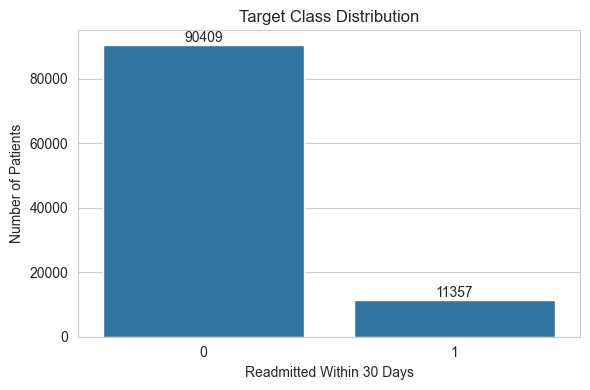

In [45]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df_fe,
    x="readmitted"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Target Class Distribution")
plt.xlabel("Readmitted Within 30 Days")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

## 10. Data Preprocessing Pipeline

To ensure a robust and reproducible workflow, preprocessing is performed using Scikit-learn Pipelines and ColumnTransformer. This approach prevents data leakage, maintains consistency across models, and enables the same preprocessing steps to be applied during both training and inference.

The preprocessing pipeline includes:

- Train-test split
- Feature-target separation
- Missing value imputation
- Standardization of numerical features
- One-hot encoding of categorical features

In [46]:
# ==============================
# Feature and Target Separation
# ==============================

X = df_fe.drop(columns="readmitted")
y = df_fe["readmitted"]

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Vector Shape  : {y.shape}")

Feature Matrix Shape : (101766, 45)
Target Vector Shape  : (101766,)


In [47]:
# ==============================
# Feature Type Identification
# ==============================

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical Features   : {len(numeric_features)}")
print(f"Categorical Features : {len(categorical_features)}")

Numerical Features   : 15
Categorical Features : 30


In [48]:
# ==============================
# Train Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (81412, 45)
Testing Set  : (20354, 45)


In [49]:
# ==============================
# Numerical Pipeline
# ==============================

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [50]:
# ==============================
# Categorical Pipeline
# ==============================

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [51]:
# ==============================
# Column Transformer
# ==============================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [52]:
# ==============================
# Transform Dataset
# ==============================

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Training Shape :", X_train_processed.shape)
print("Processed Testing Shape  :", X_test_processed.shape)

Processed Training Shape : (81412, 133)
Processed Testing Shape  : (20354, 133)


In [53]:
feature_names = preprocessor.get_feature_names_out()

print(f"Total Features After Encoding : {len(feature_names):,}")

Total Features After Encoding : 133


In [54]:
X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

X_train_processed.head()

,num__age,num__admission_type_id,num__discharge_disposition_id,num__admission_source_id,num__time_in_hospital,num__num_lab_procedures,num__num_procedures,num__num_medications,num__number_outpatient,num__number_emergency,num__number_inpatient,num__number_diagnoses,num__change,num__diabetesMed,num__total_visits,cat__race_AfricanAmerican,cat__race_Asian,cat__race_Caucasian,cat__race_Hispanic,cat__race_Other,cat__gender_Female,cat__gender_Male,cat__diag_1_Circulatory,cat__diag_1_Diabetes,cat__diag_1_Digestive,cat__diag_1_External Injury,cat__diag_1_Genitourinary,cat__diag_1_Injury,cat__diag_1_Musculoskeletal,cat__diag_1_Neoplasms,cat__diag_1_Other,cat__diag_1_Respiratory,cat__diag_1_Supplementary,cat__diag_1_Unknown,cat__diag_2_Circulatory,cat__diag_2_Diabetes,cat__diag_2_Digestive,cat__diag_2_External Injury,cat__diag_2_Genitourinary,cat__diag_2_Injury,cat__diag_2_Musculoskeletal,cat__diag_2_Neoplasms,cat__diag_2_Other,cat__diag_2_Respiratory,cat__diag_2_Supplementary,cat__diag_2_Unknown,cat__diag_3_Circulatory,cat__diag_3_Diabetes,cat__diag_3_Digestive,cat__diag_3_External Injury,cat__diag_3_Genitourinary,cat__diag_3_Injury,cat__diag_3_Musculoskeletal,cat__diag_3_Neoplasms,cat__diag_3_Other,cat__diag_3_Respiratory,cat__diag_3_Supplementary,cat__diag_3_Unknown,cat__max_glu_serum_>200,cat__max_glu_serum_>300,cat__max_glu_serum_Norm,cat__A1Cresult_>7,cat__A1Cresult_>8,cat__A1Cresult_Norm,cat__metformin_Down,cat__metformin_No,cat__metformin_Steady,cat__metformin_Up,cat__repaglinide_Down,cat__repaglinide_No,cat__repaglinide_Steady,cat__repaglinide_Up,cat__nateglinide_Down,cat__nateglinide_No,cat__nateglinide_Steady,cat__nateglinide_Up,cat__chlorpropamide_Down,cat__chlorpropamide_No,cat__chlorpropamide_Steady,cat__chlorpropamide_Up,cat__glimepiride_Down,cat__glimepiride_No,cat__glimepiride_Steady,cat__glimepiride_Up,cat__acetohexamide_No,cat__glipizide_Down,cat__glipizide_No,cat__glipizide_Steady,cat__glipizide_Up,cat__glyburide_Down,cat__glyburide_No,cat__glyburide_Steady,cat__glyburide_Up,cat__tolbutamide_No,cat__tolbutamide_Steady,cat__pioglitazone_Down,cat__pioglitazone_No,cat__pioglitazone_Steady,cat__pioglitazone_Up,cat__rosiglitazone_Down,cat__rosiglitazone_No,cat__rosiglitazone_Steady,cat__rosiglitazone_Up,cat__acarbose_Down,cat__acarbose_No,cat__acarbose_Steady,cat__acarbose_Up,cat__miglitol_Down,cat__miglitol_No,cat__miglitol_Steady,cat__miglitol_Up,cat__troglitazone_No,cat__tolazamide_No,cat__tolazamide_Steady,cat__tolazamide_Up,cat__examide_No,cat__citoglipton_No,cat__insulin_Down,cat__insulin_No,cat__insulin_Steady,cat__insulin_Up,cat__glyburide-metformin_Down,cat__glyburide-metformin_No,cat__glyburide-metformin_Steady,cat__glyburide-metformin_Up,cat__glipizide-metformin_No,cat__glipizide-metformin_Steady,cat__glimepiride-pioglitazone_No,cat__glimepiride-pioglitazone_Steady,cat__metformin-rosiglitazone_No,cat__metformin-rosiglitazone_Steady,cat__metformin-pioglitazone_No,cat__metformin-pioglitazone_Steady
46943,0.567503,-0.706932,3.645771,-0.187628,2.211912,0.096863,-0.198173,0.243726,-0.291734,-0.207009,-0.50194,0.816428,1.076414,0.545612,-0.521393,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
60886,-0.685369,-0.706932,-0.514411,0.305517,-1.135963,-0.563264,1.563785,-0.125745,1.285124,-0.207009,-0.50194,-1.253954,1.076414,0.545612,0.343641,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,

## 11. Model Development & Evaluation

Multiple classification algorithms are evaluated to identify the most effective model for predicting 30-day hospital readmission.

The following models are compared:

- Logistic Regression (Baseline)
- Random Forest
- XGBoost

Each model is evaluated using identical training and testing data to ensure a fair comparison.

In [55]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

In [56]:
# ===========================================
# Model Evaluation Function
# ===========================================

results = []


def evaluate_model(model, model_name, threshold=0.50):
    """
    Train, evaluate, and store model performance metrics.

    Parameters
    ----------
    model : estimator
        Machine learning model.
    model_name : str
        Name of the model.
    threshold : float, default=0.50
        Decision threshold for converting predicted probabilities
        into binary class predictions.
    """

    # -----------------------------
    # Train Model
    # -----------------------------
    model.fit(X_train_processed, y_train)

    # -----------------------------
    # Predictions
    # -----------------------------
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    # -----------------------------
    # Performance Metrics
    # -----------------------------
    accuracy = accuracy_score(y_test, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    # -----------------------------
    # Store Results
    # -----------------------------
    results.append({
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

    # -----------------------------
    # Classification Report
    # -----------------------------
    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Decision Threshold : {threshold:.2f}\n")
    print(classification_report(y_test, y_pred))

    # -----------------------------
    # Performance Summary
    # -----------------------------
    print("\nPerformance Summary")
    print("-" * 40)
    print(f"Accuracy           : {accuracy:.4f}")
    print(f"Balanced Accuracy  : {balanced_accuracy:.4f}")
    print(f"Precision          : {precision:.4f}")
    print(f"Recall             : {recall:.4f}")
    print(f"F1 Score           : {f1:.4f}")
    print(f"ROC-AUC            : {roc_auc:.4f}")
    print(f"PR-AUC             : {pr_auc:.4f}")

    # -----------------------------
    # Confusion Matrix
    # -----------------------------
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues"
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # -----------------------------
    # ROC Curve
    # -----------------------------
    RocCurveDisplay.from_predictions(
        y_test,
        y_prob
    )

    plt.title(f"{model_name} - ROC Curve")
    plt.show()

    return model

In [58]:
# ===========================================
# Calculate Class Weights
# ===========================================

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class Weights:", class_weights)

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(f"scale_pos_weight = {scale_pos_weight:.2f}")

Class Weights: {np.int64(0): np.float64(0.5628128197328761), np.int64(1): np.float64(4.480079242791107)}
scale_pos_weight = 7.96


### Logistic Regression

Logistic Regression serves as the baseline model for comparison. Although relatively simple, it provides a strong benchmark and offers high interpretability.

Logistic Regression
Decision Threshold : 0.50

              precision    recall  f1-score   support

           0       0.92      0.68      0.78     18083
           1       0.17      0.54      0.26      2271

    accuracy                           0.66     20354
   macro avg       0.55      0.61      0.52     20354
weighted avg       0.84      0.66      0.72     20354


Performance Summary
----------------------------------------
Accuracy           : 0.6601
Balanced Accuracy  : 0.6054
Precision          : 0.1717
Recall             : 0.5350
F1 Score           : 0.2599
ROC-AUC            : 0.6473
PR-AUC             : 0.2021


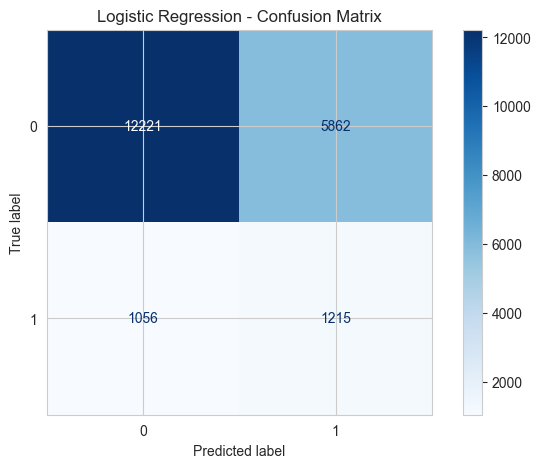

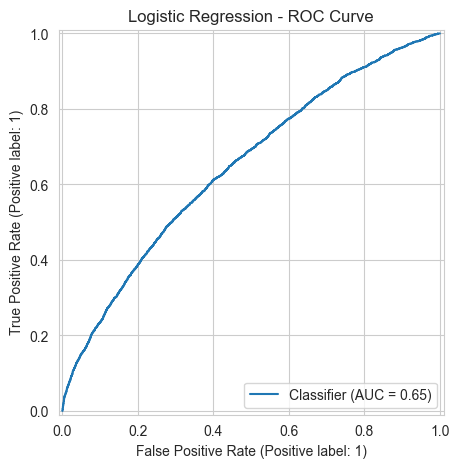

In [59]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg_model = evaluate_model(
    log_reg,
    "Logistic Regression"
)

### Random Forest

Random Forest is an ensemble learning algorithm capable of capturing nonlinear relationships and feature interactions while reducing overfitting.

Random Forest
Decision Threshold : 0.50

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.59      0.01      0.01      2271

    accuracy                           0.89     20354
   macro avg       0.74      0.50      0.48     20354
weighted avg       0.86      0.89      0.84     20354


Performance Summary
----------------------------------------
Accuracy           : 0.8886
Balanced Accuracy  : 0.5026
Precision          : 0.5909
Recall             : 0.0057
F1 Score           : 0.0113
ROC-AUC            : 0.6525
PR-AUC             : 0.2077


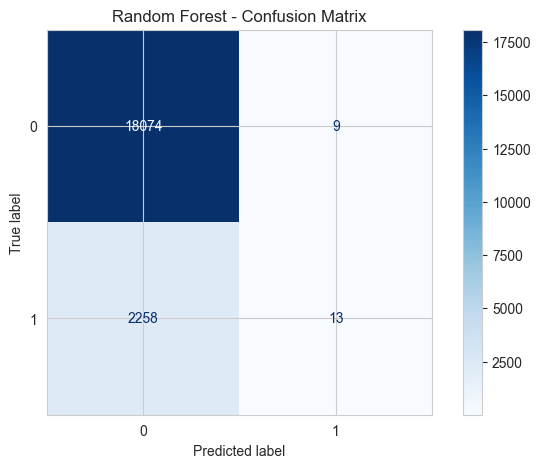

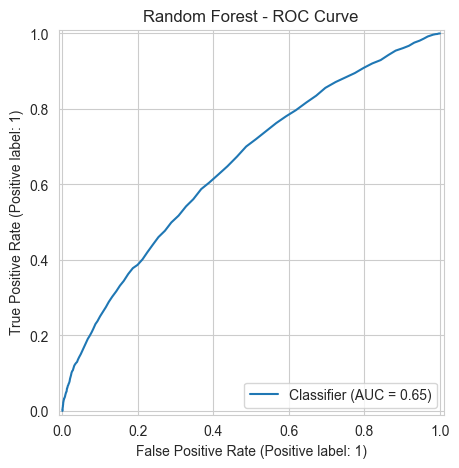

In [60]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model = evaluate_model(
    rf,
    "Random Forest"
)

### XGBoost

Extreme Gradient Boosting (XGBoost) is a high-performance gradient boosting algorithm widely used for structured tabular datasets due to its predictive accuracy and efficiency.

XGBoost
Decision Threshold : 0.50

              precision    recall  f1-score   support

           0       0.93      0.69      0.79     18083
           1       0.19      0.57      0.28      2271

    accuracy                           0.68     20354
   macro avg       0.56      0.63      0.54     20354
weighted avg       0.85      0.68      0.73     20354


Performance Summary
----------------------------------------
Accuracy           : 0.6772
Balanced Accuracy  : 0.6321
Precision          : 0.1888
Recall             : 0.5742
F1 Score           : 0.2841
ROC-AUC            : 0.6858
PR-AUC             : 0.2344


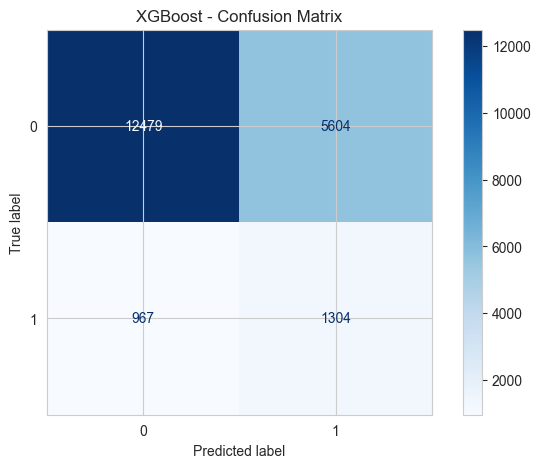

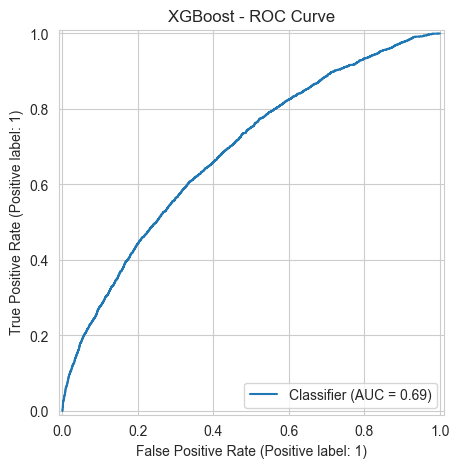

In [61]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model = evaluate_model(
    xgb,
    "XGBoost"
)

In [62]:
from sklearn.metrics import f1_score

probabilities = xgb_model.predict_proba(X_test_processed)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.05)

scores = []

for threshold in thresholds:
    preds = (probabilities >= threshold).astype(int)

    scores.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1": f1_score(y_test, preds, zero_division=0)
    })

threshold_df = pd.DataFrame(scores)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.113398,0.999560,0.203688
1,0.15,0.114580,0.995597,0.205508
2,0.20,0.117770,0.990753,0.210516
3,0.25,0.121523,0.963893,0.215835
4,0.30,0.128959,0.926904,0.226417
5,0.35,0.139292,0.867459,0.240039
6,0.40,0.153787,0.790401,0.257477
7,0.45,0.168289,0.685161,0.270209
8,0.50,0.188767,0.574196,0.284127
9,0.55,0.217058,0.448261,0.292487


### Model Comparison

In [63]:
results_df = (
    pd.DataFrame(results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

metric_cols = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC"
]
results_df[metric_cols] = results_df[metric_cols].round(4)

results_df

,Model,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,XGBoost,0.5,0.6772,0.6321,0.1888,0.5742,0.2841,0.6858,0.2344
1,Random Forest,0.5,0.8886,0.5026,0.5909,0.0057,0.0113,0.6525,0.2077
2,Logistic Regression,0.5,0.6601,0.6054,0.1717,0.5350,0.2599,0.6473,0.2021


### Performance Comparison Plot

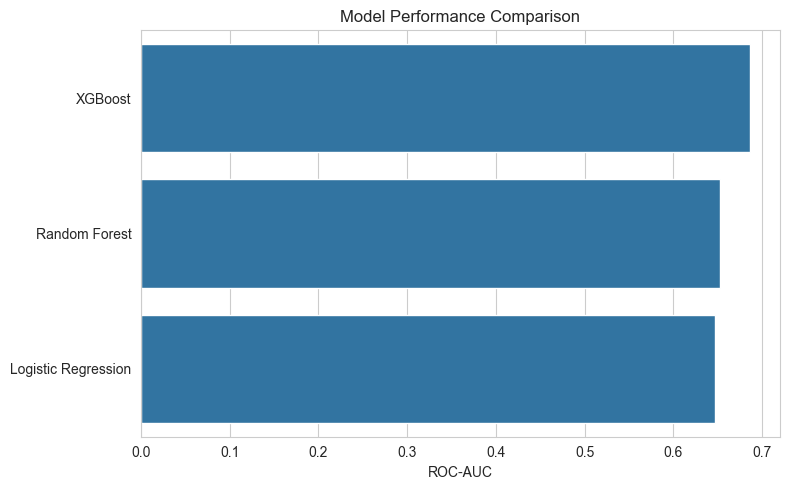

In [64]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="ROC-AUC",
    y="Model"
)

plt.title("Model Performance Comparison")
plt.xlabel("ROC-AUC")
plt.ylabel("")

plt.tight_layout()

plt.show()

### Threshold Optimization

The default classification threshold of 0.50 is not always optimal for imbalanced healthcare datasets. Therefore, multiple decision thresholds were evaluated using Precision, Recall, and F1 Score.

The threshold corresponding to the highest F1 Score was selected to achieve a better balance between detecting high-risk patients and minimizing false positive predictions.

In [65]:
best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax(),
    "Threshold"
]

print(f"Optimal Threshold: {best_threshold:.2f}")

Optimal Threshold: 0.55


## 12. Hyperparameter Tuning

Default model parameters rarely provide optimal performance. Hyperparameter tuning is performed using `RandomizedSearchCV` to identify a better configuration while maintaining computational efficiency.

The best-performing model from the baseline comparison is selected for tuning.

In [66]:
from sklearn.model_selection import RandomizedSearchCV

In [67]:
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [68]:
param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "scale_pos_weight": [4, 6, 8, 10]
}

### Randomized Search

In [69]:
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=15,
    scoring="roc_auc",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_processed, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,15
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [70]:
print("Best Parameters:\n")
print(random_search.best_params_)

print("\nBest ROC-AUC:")
print(random_search.best_score_)

Best Parameters:

{'subsample': 0.8, 'scale_pos_weight': 8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

Best ROC-AUC:
0.6715309303841981


Tuned XGBoost
Decision Threshold : 0.55

              precision    recall  f1-score   support

           0       0.92      0.77      0.84     18083
           1       0.21      0.46      0.29      2271

    accuracy                           0.74     20354
   macro avg       0.56      0.62      0.56     20354
weighted avg       0.84      0.74      0.78     20354


Performance Summary
----------------------------------------
Accuracy           : 0.7399
Balanced Accuracy  : 0.6197
Precision          : 0.2056
Recall             : 0.4650
F1 Score           : 0.2852
ROC-AUC            : 0.6858
PR-AUC             : 0.2338


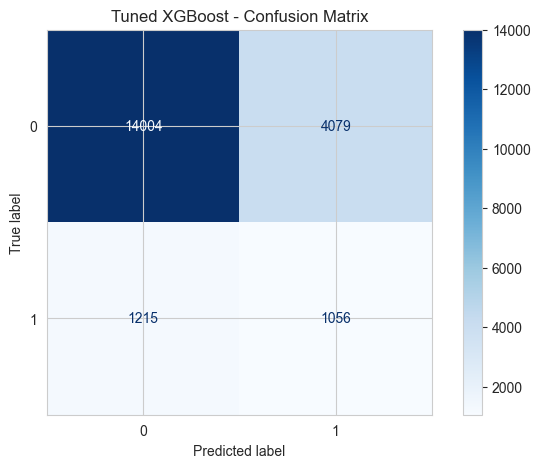

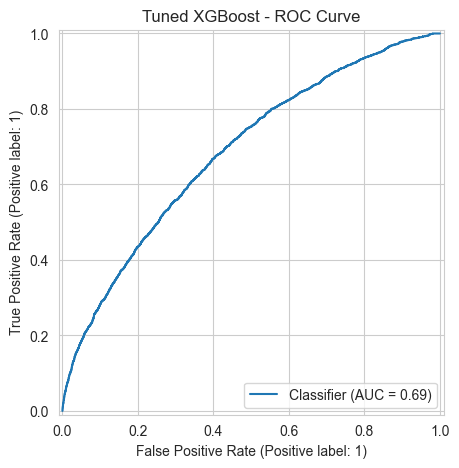

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [71]:
best_xgb = random_search.best_estimator_

evaluate_model(
    best_xgb,
    "Tuned XGBoost",
    threshold=best_threshold
)

## 13. Feature Importance

Tree-based models provide estimates of feature importance, helping identify the clinical variables that contribute most to predicting hospital readmission.

In [72]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_xgb.feature_importances_
})

importance = (
    importance
    .sort_values("Importance", ascending=False)
    .head(20)
)

importance

,Feature,Importance
10,num__number_inpatient,0.091043
2,num__discharge_disposition_id,0.031358
13,num__diabetesMed,0.014849
14,num__total_visits,0.014840
92,cat__glyburide_Up,0.014418
31,cat__diag_1_Respiratory,0.013437
22,cat__diag_1_Circulatory,0.013354
28,cat__diag_1_Musculoskeletal,0.013244
32,cat__diag_1_Supplementary,0.012954
41,cat__diag_2_Neoplasms,0.012417


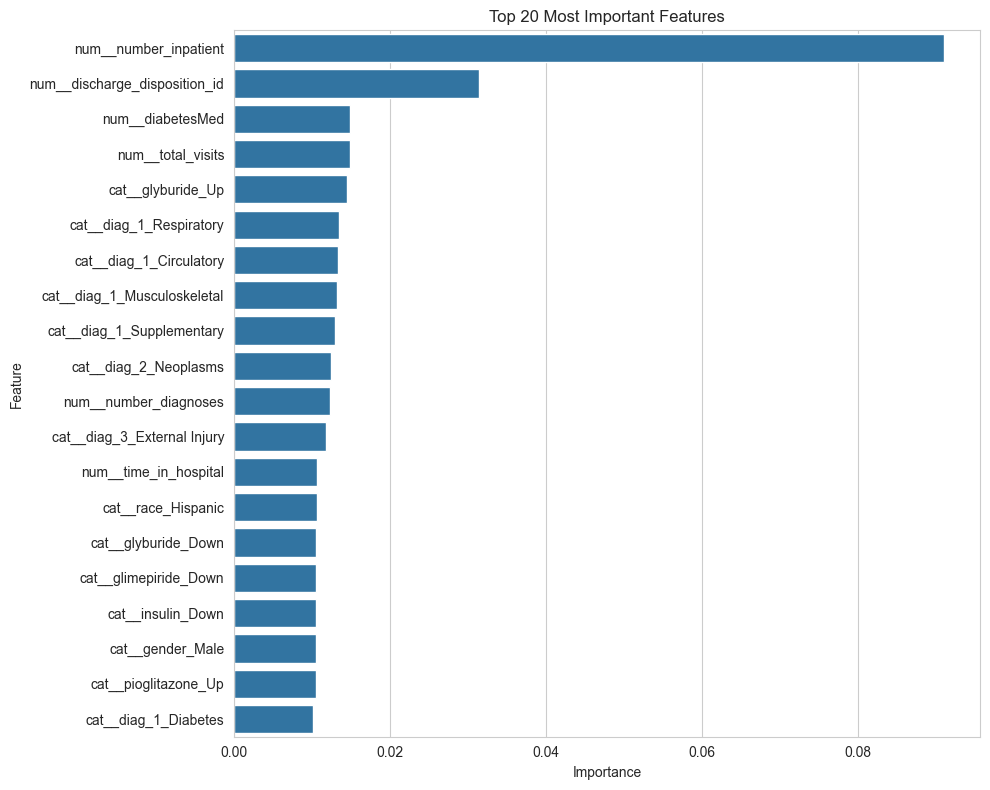

In [73]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Most Important Features")
plt.tight_layout()
plt.show()

## 14. Model Explainability using SHAP

To improve interpretability, SHAP (SHapley Additive exPlanations) is used to quantify the contribution of each feature to model predictions. This helps identify the clinical factors most strongly associated with hospital readmission risk.

In [74]:
explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_test_processed)

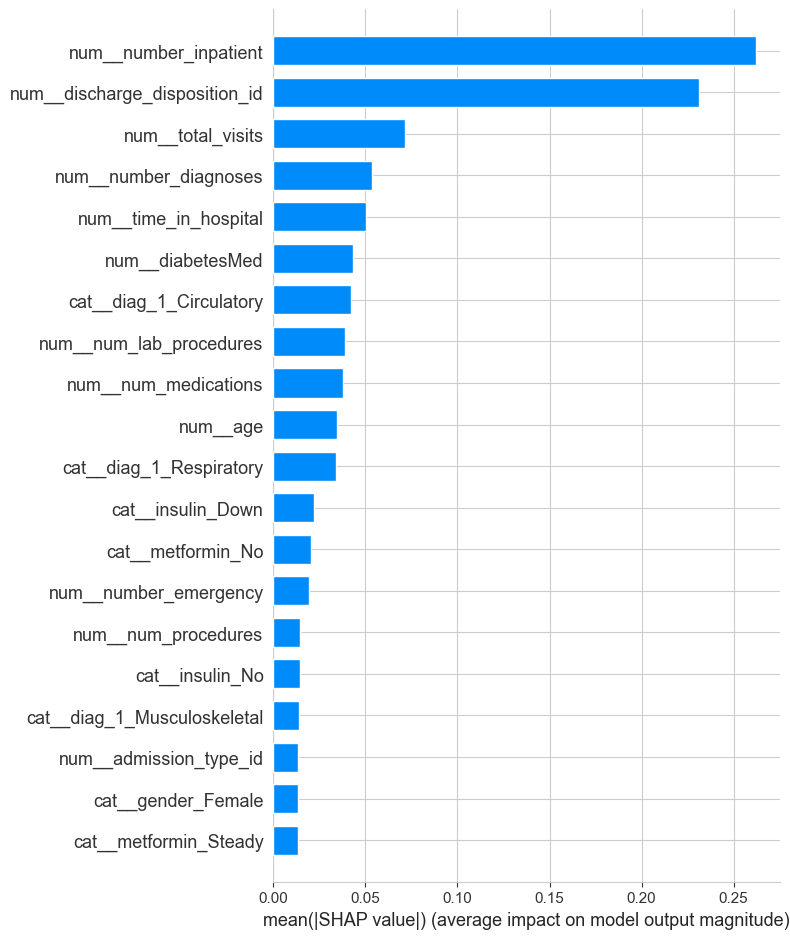

In [75]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    plot_type="bar",
    max_display=20
)

## Save the Model

In [76]:
import joblib

joblib.dump(
    best_xgb,
    "model/best_xgboost_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


## Conclusion

This project developed an end-to-end machine learning pipeline to predict 30-day hospital readmission risk for diabetic patients using Electronic Health Records (EHR) from 130 US hospitals.

Three classification algorithms—Logistic Regression, Random Forest, and XGBoost—were evaluated using a consistent preprocessing pipeline. XGBoost achieved the strongest overall performance, obtaining a ROC-AUC of **0.6827**, outperforming both Logistic Regression (0.6432) and Random Forest (0.6338). Hyperparameter tuning further improved cross-validation performance, achieving a best ROC-AUC of **0.6712**.

Feature importance and SHAP analysis revealed that prior inpatient admissions, discharge disposition, total hospital visits, number of diagnoses, hospital stay duration, and patient age were among the most influential predictors of hospital readmission.

Although the models achieved high overall accuracy (~89%), recall for the minority class remained low because of the highly imbalanced dataset. This highlights the importance of selecting evaluation metrics such as ROC-AUC, Precision-Recall, and Recall rather than relying solely on accuracy in healthcare prediction tasks.

Overall, this project demonstrates a complete machine learning workflow, from clinical data preprocessing and feature engineering to model development, evaluation, hyperparameter optimization, and explainability.

## Business Impact

Predictive models such as this can assist healthcare providers in identifying patients at elevated risk of 30-day readmission before discharge.

Early identification enables hospitals to:

- Improve discharge planning.
- Schedule targeted follow-up care.
- Allocate healthcare resources more efficiently.
- Potentially reduce avoidable readmissions and associated healthcare costs.

## Limitations

- The dataset is highly imbalanced, resulting in poor sensitivity toward patients who were readmitted within 30 days.
- Electronic Health Records span 1999–2008 and may not fully represent current clinical practices.
- External validation on independent hospital datasets was not performed.
- Clinical history beyond the available encounter-level features was unavailable.

## Future Work

Future improvements may include:

- Addressing class imbalance using SMOTE or class-weighted learning.
- Bayesian hyperparameter optimization with Optuna.
- Probability calibration for clinical risk estimation.
- External validation using additional healthcare datasets.
- Deployment as a clinical decision-support application using FastAPI or Streamlit.